# sin(x) 的 9 点三次样条插值

区间：$[0,2\pi]$  
节点数：9

本 Notebook 包含：

1. 使用 `scipy.interpolate.CubicSpline` 构造自然三次样条；
2. 绘制三次样条插值曲线；
3. 绘制插值绝对误差；
4. 输出每个区间上的三次多项式系数；
5. 图片自动保存为 PNG 文件。

In [1]:
"""
============================================================
sin(x) 的 9 点三次样条插值
------------------------------------------------------------

区间：[0, 2π]
节点数：9

实现内容：

1. 构造自然三次样条插值函数
2. 绘制三次样条插值曲线
3. 绘制三次样条插值误差
4. 输出各区间三次多项式系数

每张图都会：

- 在 Jupyter Notebook 中显示
- 自动保存为 PNG 文件

依赖库：

numpy
matplotlib
scipy

============================================================
"""

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


# 如果 Figures 文件夹不存在，则自动创建
os.makedirs("Figures", exist_ok=True)


In [2]:
# 在区间 [0, 2π] 上构造 9 个等距插值节点
x_nodes = np.linspace(
    0.0,
    2.0 * np.pi,
    9
)

# 节点对应的函数值
y_nodes = np.sin(x_nodes)


# 构造致密网格，用于绘图和误差计算
x = np.linspace(
    0.0,
    2.0 * np.pi,
    2000
)

# 原函数真值
y_true = np.sin(x)


# 构造自然三次样条插值函数
# bc_type="natural" 表示左右端点的二阶导数为 0
spline = CubicSpline(
    x_nodes,
    y_nodes,
    bc_type="natural"
)

# 计算样条插值结果
y_spline = spline(x)

# 计算绝对误差
error_spline = np.abs(
    y_spline - y_true
)

print(
    "三次样条插值最大绝对误差：",
    np.max(error_spline)
)


三次样条插值最大绝对误差： 0.0010660807846212261


/tmp/ipykernel_518956/1221540415.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

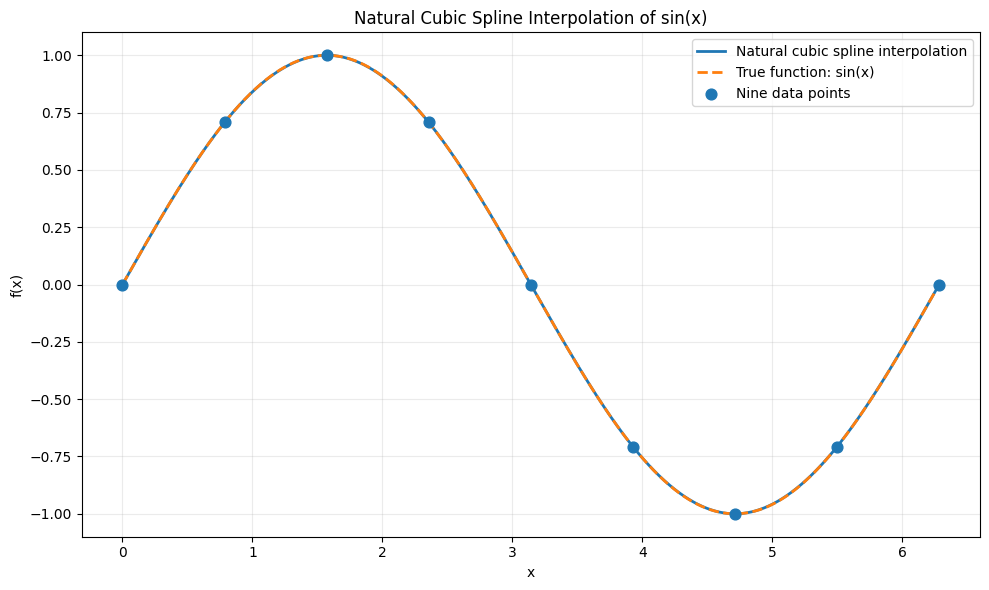

/tmp/ipykernel_518956/1221540415.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/tmp/ipykernel_518956/1221540415.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

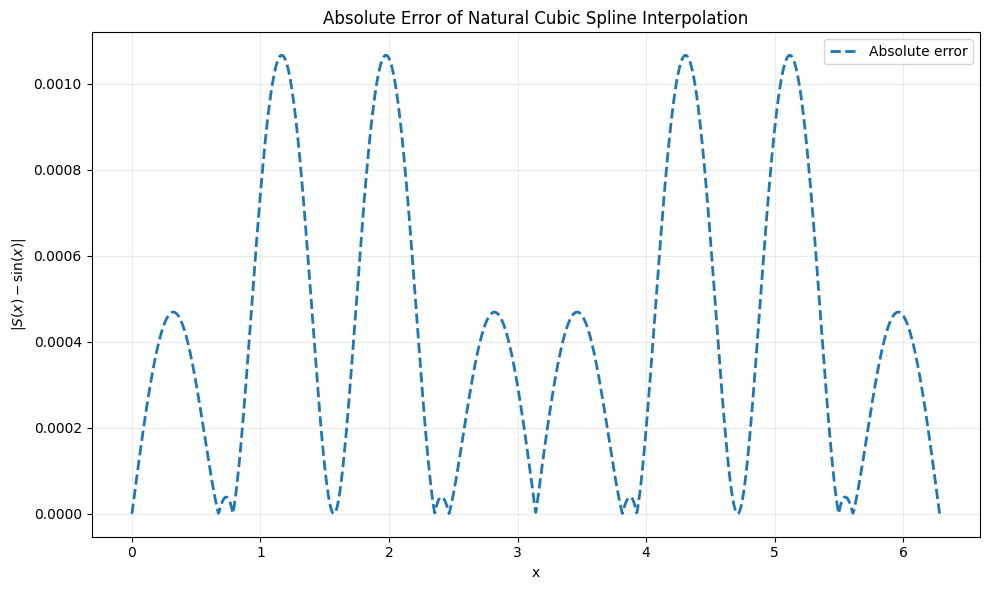

In [3]:
# ==========================================================
# 三次样条插值曲线
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    x_nodes,
    y_nodes,
    s=60,
    label="Nine data points",
    zorder=3
)

plt.plot(
    x,
    y_spline,
    linewidth=2,
    label="Natural cubic spline interpolation"
)

plt.plot(
    x,
    y_true,
    "--",
    linewidth=2,
    label="True function: sin(x)"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Natural Cubic Spline Interpolation of sin(x)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figures/cubic_spline_interpolation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# 三次样条插值误差
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    error_spline,
    "--",
    linewidth=2,
    label="Absolute error"
)

plt.xlabel("x")
plt.ylabel(r"$|S(x)-\sin(x)|$")
plt.title("Absolute Error of Natural Cubic Spline Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Figures/cubic_spline_interpolation_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [4]:
# 输出各区间上的三次样条多项式系数
#
# scipy 的 CubicSpline 在第 i 个区间 [x_i, x_{i+1}] 上采用：
#
# S_i(x) = c[0,i](x-x_i)^3
#        + c[1,i](x-x_i)^2
#        + c[2,i](x-x_i)
#        + c[3,i]

print("各区间上的三次样条多项式：")
print()

for i in range(len(x_nodes) - 1):
    a = spline.c[0, i]
    b = spline.c[1, i]
    c = spline.c[2, i]
    d = spline.c[3, i]

    print(
        f"区间 [{x_nodes[i]:.6f}, {x_nodes[i+1]:.6f}]："
    )
    print(
        f"S_{i}(x) = "
        f"{a:.10e}(x-{x_nodes[i]:.6f})^3 + "
        f"{b:.10e}(x-{x_nodes[i]:.6f})^2 + "
        f"{c:.10e}(x-{x_nodes[i]:.6f}) + "
        f"{d:.10e}"
    )
    print()


各区间上的三次样条多项式：

区间 [0.000000, 0.785398]：
S_0(x) = -1.5791351047e-01(x-0.000000)^3 + -1.3877787808e-16(x-0.000000)^2 + 9.9772530853e-01(x-0.000000) + 0.0000000000e+00

区间 [0.785398, 1.570796]：
S_1(x) = -6.5409917717e-02(x-0.785398)^3 + -3.7207494329e-01(x-0.785398)^2 + 7.0549833142e-01(x-0.785398) + 7.0710678119e-01

区间 [1.570796, 2.356194]：
S_2(x) = 6.5409917717e-02(x-1.570796)^3 + -5.2619343102e-01(x-1.570796)^2 + 6.4535941352e-17(x-1.570796) + 1.0000000000e+00

区间 [2.356194, 3.141593]：
S_3(x) = 1.5791351047e-01(x-2.356194)^3 + -3.7207494329e-01(x-2.356194)^2 + -7.0549833142e-01(x-2.356194) + 7.0710678119e-01

区间 [3.141593, 3.926991]：
S_4(x) = 1.5791351047e-01(x-3.141593)^3 + 4.3021142204e-16(x-3.141593)^2 + -9.9772530853e-01(x-3.141593) + 1.2246467991e-16

区间 [3.926991, 4.712389]：
S_5(x) = 6.5409917717e-02(x-3.926991)^3 + 3.7207494329e-01(x-3.926991)^2 + -7.0549833142e-01(x-3.926991) + -7.0710678119e-01

区间 [4.712389, 5.497787]：
S_6(x) = -6.5409917717e-02(x-4.712389)^3 + 5.2619343102e

In [5]:
# 检查样条在节点处是否通过所有数据点

node_errors = np.abs(
    spline(x_nodes) - y_nodes
)

print("各节点处的插值误差：")
print(node_errors)

print()
print(
    "节点处最大误差：",
    np.max(node_errors)
)


各节点处的插值误差：
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.26263963e-17]

节点处最大误差： 3.2626396326818494e-17
